In [1]:
import seaborn as sns
sns.load_dataset('tips')

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [2]:
type(sns.load_dataset('tips'))

pandas.core.frame.DataFrame

In [3]:
df = sns.load_dataset('tips')

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [7]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [8]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [9]:
df['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [10]:
# Here we need to apply Feature Encoding-:
# there are 2 types of feature encoding techniques majorily used-:
# 1) Label encoding  -: used when threr are only 2 categories of a CLASS
# 2) One Hot encoding -: used when there are more than 2 categories of a CLASS

In [ ]:
# For time; smoker and sex => Label Encoding
# For day => ONE HOT Encoding

In [11]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [13]:
# Independent features in X-:
X = df[['tip', 'sex', 'smoker', 'day', 'time', 'size']]
# dependent feature in y-:
y = df['total_bill']

It is always NECESSARY to do train_test_split first and then apply the encoding technique in order to prevent DATA LEAKAGE to the MODEL.

In [14]:
# train-test-split-:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=10)

In [15]:
X_train

,tip,sex,smoker,day,time,size
58,1.76,Male,Yes,Sat,Dinner,2
1,1.66,Male,No,Sun,Dinner,3
2,3.50,Male,No,Sun,Dinner,3
68,2.01,Male,No,Sat,Dinner,2
184,3.00,Male,Yes,Sun,Dinner,2
...,...,...,...,...,...,...
64,2.64,Male,No,Sat,Dinner,3
15,3.92,Male,No,Sun,Dinner,2
228,2.72,Male,No,Sat,Dinner,2
125,4.20,Female,No,Thur,Lunch,6


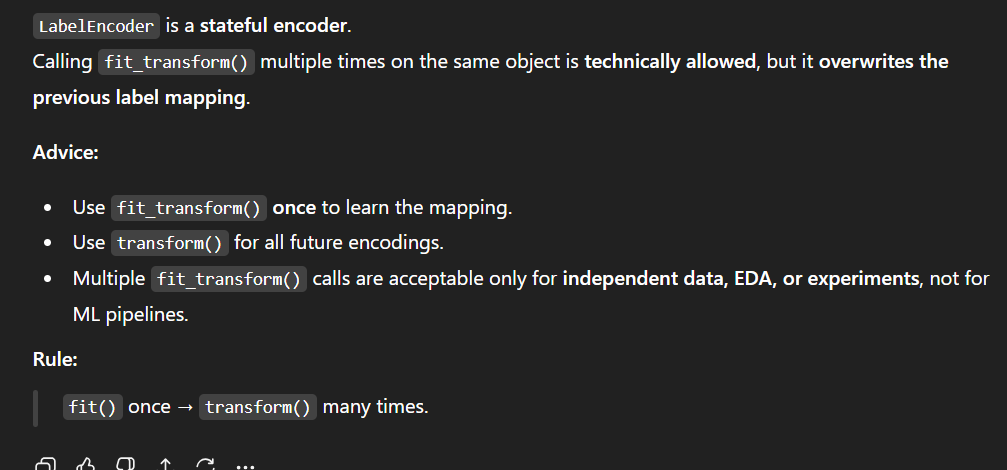

So; ALWAYS use different SEPERATE label-encoders for each I/P feature as u would require that same label encoder to be applied on test-data for that particular FEATURE MULTIPLE TIMES.

In [ ]:
from sklearn.preprocessing import LabelEncoder
le1 = LabelEncoder() # for sex
le2 = LabelEncoder() # for smoker
le3 = LabelEncoder() # for time

In [20]:
X_train['sex']=le1.fit_transform(X_train['sex'])

In [21]:
X_train['smoker']=le2.fit_transform(X_train["smoker"])

In [22]:
X_train['time']=le3.fit_transform(X_train['time'])

In [24]:
# Used for ignoring warnings from the compiler and NOT showing them on the OUTPUT logger-:
import warnings
warnings.filterwarnings('ignore')

In [25]:
X_train.head()

,tip,sex,smoker,day,time,size
58,1.76,1,1,Sat,0,2
1,1.66,1,0,Sun,0,3
2,3.50,1,0,Sun,0,3
68,2.01,1,0,Sat,0,2
184,3.00,1,1,Sun,0,2


In [26]:
X_test['sex'] = le1.transform(X_test['sex'])
X_test['smoker'] = le2.transform(X_test['smoker'])
X_test['time'] = le3.transform(X_test['time'])

In [27]:
X_test.head()

,tip,sex,smoker,day,time,size
162,2.00,0,0,Sun,0,3
60,3.21,1,1,Sat,0,2
61,2.00,1,1,Sat,0,2
63,3.76,1,1,Sat,0,4
69,2.09,1,1,Sat,0,2


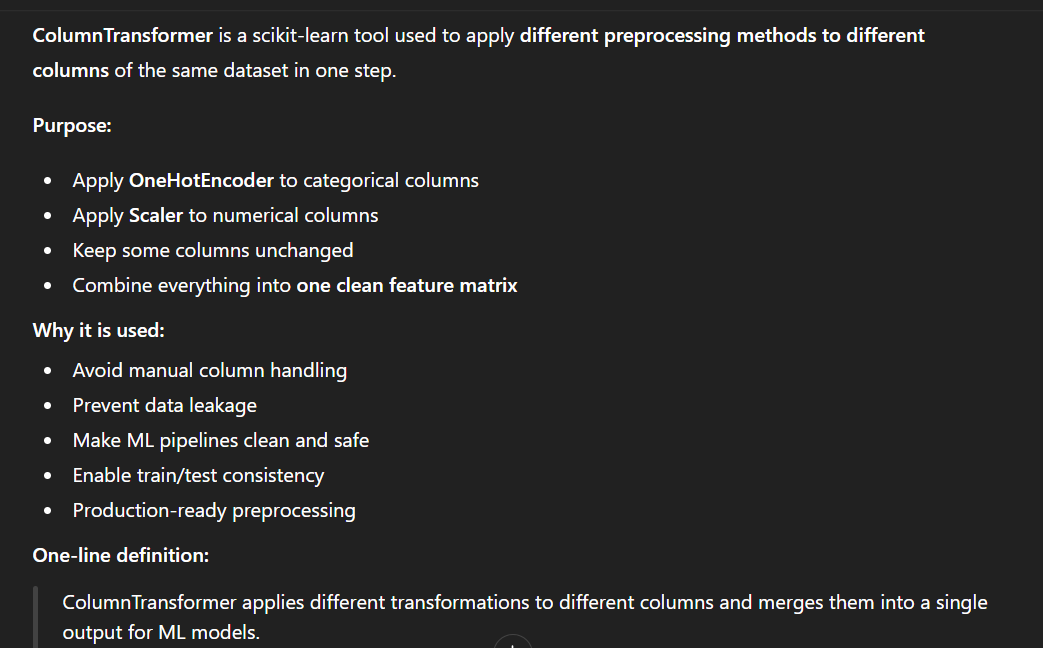
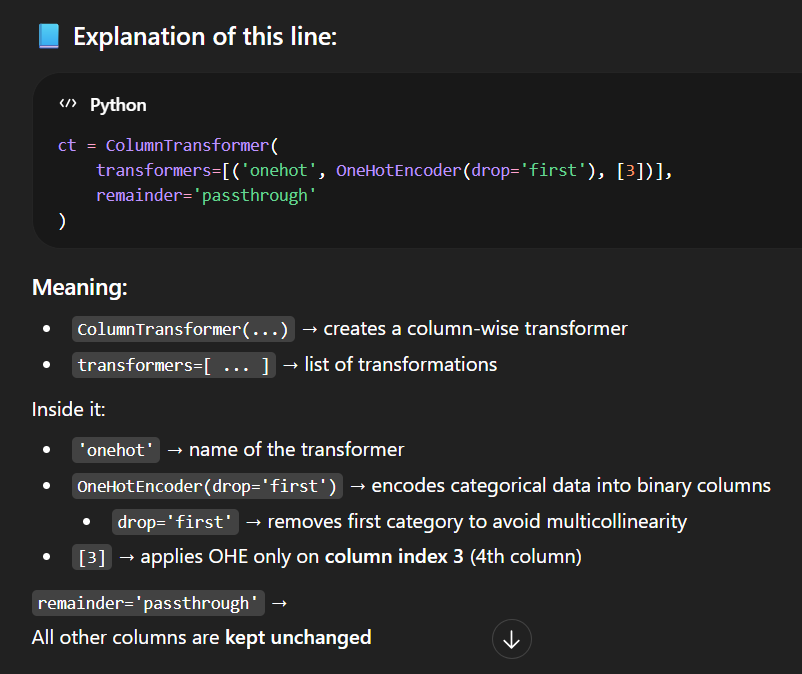

In [28]:
# OHE --- Column Transformer-:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [32]:
ct = ColumnTransformer(
    transformers=[
    ('onehot',OneHotEncoder(drop='first'),[3])
    ], remainder='passthrough'
)

# [3] index is of -: "day" column
# Always pass the index-value in the form of list only always like this-: [3]

In [36]:
import sys
import numpy

numpy.set_printoptions(threshold=sys.maxsize)
X_train = ct.fit_transform(X_train)
# In this below O/P first three column values are result of OHE via Column-transformer and rest are reaming columns of the tips dataset which are kept as it is.
# If all OHE colums are '0' then day is 'Thur' as it got droped by drop='first' as it was ALPHABETICALLY FIRST.

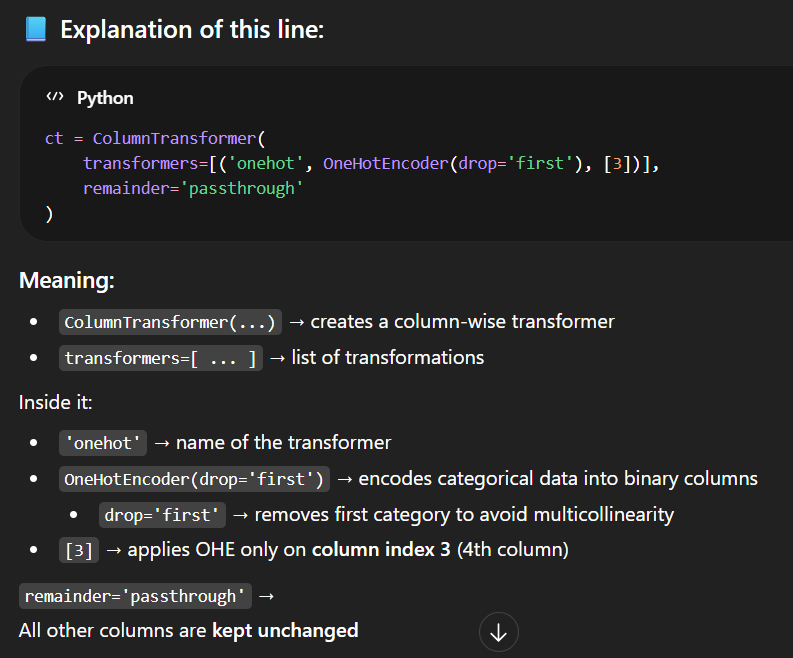

name of the transformer can be anyhthing but adviced to keep relevant

In simple words:
Apply OneHotEncoding on column 3, keep all other columns as they are.

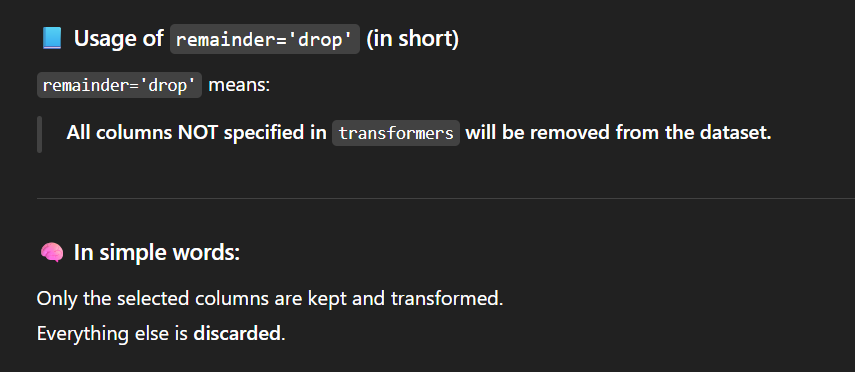


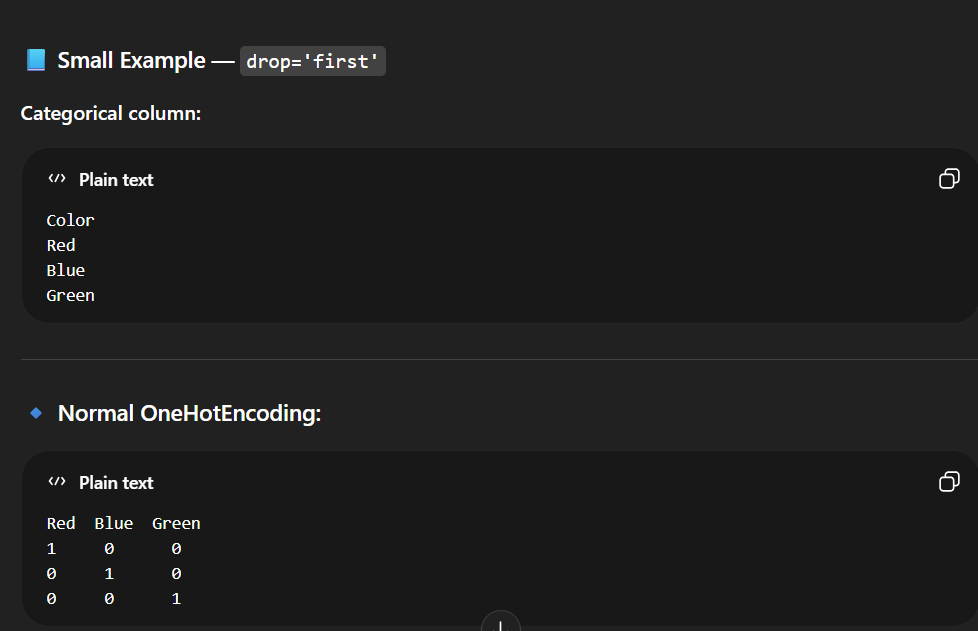

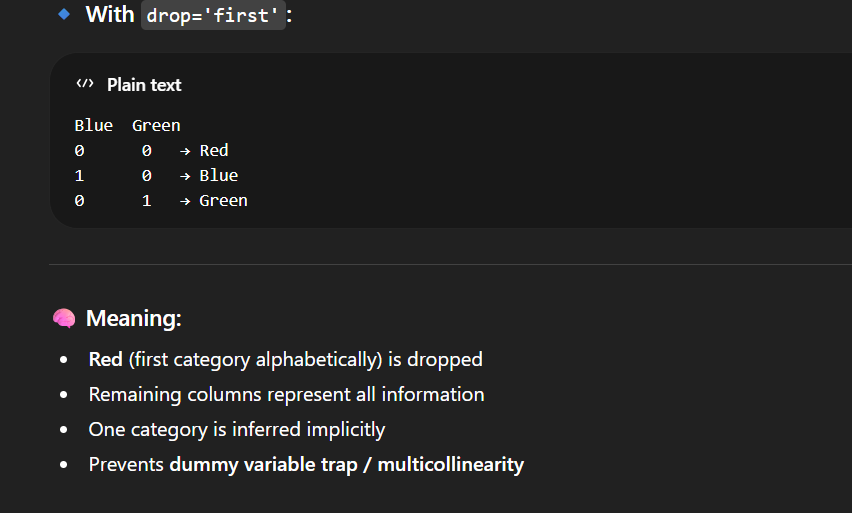

drop='first' removes the first encoded category, not a dataset column.
as according to values of other columns we can predict whether the data-point is of first encoded category or not like we can see in 'Red' example

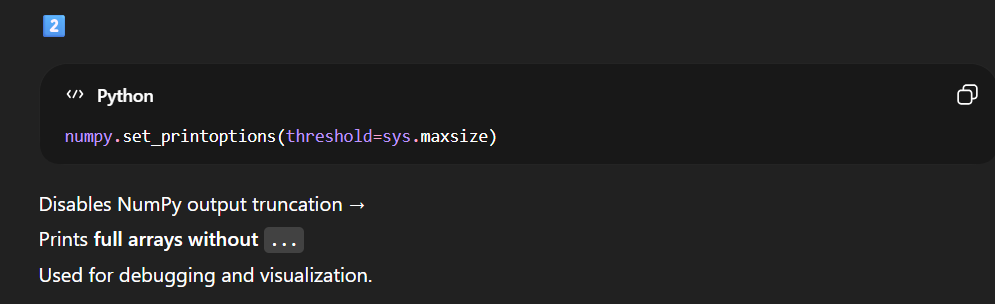
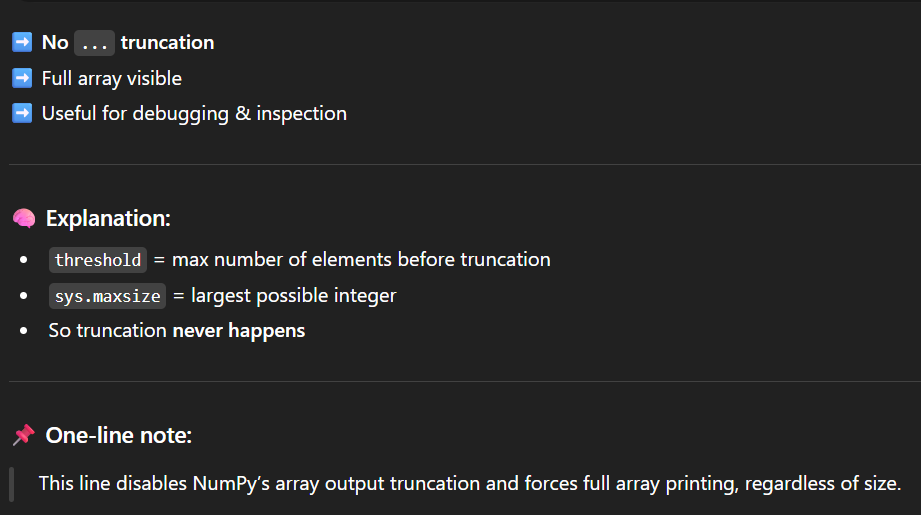

In [37]:
X_test = ct.transform(X_test)

In [38]:
X_train

array([[ 1.  ,  0.  ,  0.  ,  1.76,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  ,  1.66,  1.  ,  0.  ,  0.  ,  3.  ],
       [ 0.  ,  1.  ,  0.  ,  3.5 ,  1.  ,  0.  ,  0.  ,  3.  ],
       [ 1.  ,  0.  ,  0.  ,  2.01,  1.  ,  0.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  ,  3.  ,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  ,  4.  ,  0.  ,  1.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  ,  5.2 ,  0.  ,  0.  ,  0.  ,  4.  ],
       [ 0.  ,  0.  ,  1.  ,  4.  ,  1.  ,  1.  ,  1.  ,  4.  ],
       [ 0.  ,  0.  ,  1.  ,  5.  ,  1.  ,  0.  ,  1.  ,  5.  ],
       [ 1.  ,  0.  ,  0.  ,  3.  ,  0.  ,  0.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  ,  1.75,  1.  ,  0.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  ,  3.12,  1.  ,  0.  ,  0.  ,  4.  ],
       [ 0.  ,  0.  ,  1.  ,  3.  ,  0.  ,  0.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  ,  5.  ,  1.  ,  0.  ,  0.  ,  3.  ],
       [ 0.  ,  0.  ,  1.  ,  4.  ,  1.  ,  0.  ,  1.  ,  2.  ],
       [ 1.  ,  0.  ,  0.

In [39]:
X_test

array([[0.  , 1.  , 0.  , 2.  , 0.  , 0.  , 0.  , 3.  ],
       [1.  , 0.  , 0.  , 3.21, 1.  , 1.  , 0.  , 2.  ],
       [1.  , 0.  , 0.  , 2.  , 1.  , 1.  , 0.  , 2.  ],
       [1.  , 0.  , 0.  , 3.76, 1.  , 1.  , 0.  , 4.  ],
       [1.  , 0.  , 0.  , 2.09, 1.  , 1.  , 0.  , 2.  ],
       [0.  , 0.  , 1.  , 5.  , 1.  , 1.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 3.51, 1.  , 0.  , 0.  , 2.  ],
       [1.  , 0.  , 0.  , 5.16, 1.  , 1.  , 0.  , 4.  ],
       [0.  , 1.  , 0.  , 5.  , 1.  , 0.  , 0.  , 2.  ],
       [1.  , 0.  , 0.  , 3.6 , 1.  , 0.  , 0.  , 3.  ],
       [0.  , 1.  , 0.  , 5.65, 1.  , 1.  , 0.  , 2.  ],
       [1.  , 0.  , 0.  , 2.5 , 0.  , 1.  , 0.  , 3.  ],
       [0.  , 0.  , 1.  , 1.44, 1.  , 0.  , 1.  , 2.  ],
       [1.  , 0.  , 0.  , 3.09, 0.  , 1.  , 0.  , 4.  ],
       [0.  , 1.  , 0.  , 2.  , 1.  , 0.  , 0.  , 4.  ],
       [0.  , 0.  , 1.  , 1.36, 0.  , 0.  , 1.  , 3.  ],
       [0.  , 0.  , 1.  , 2.  , 0.  , 0.  , 1.  , 2.  ],
       [0.  , 0.  , 1.  , 1.68,

In [40]:
# SVR --> Support Vector Regressor-: 
from sklearn.svm import SVR
svr = SVR()

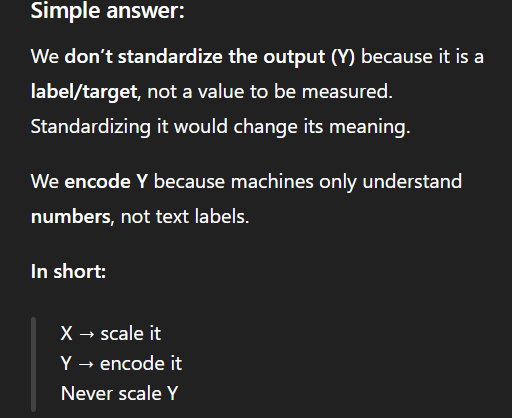

for this reason we did not standardized the Y (O/P) feature

In [41]:
svr.fit(X_train,y_train)

SVR()

In [42]:
y_pred = svr.predict(X_test)

In [43]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.46028114561159283
4.1486423210190235


# HYPER-PARAMETER TUNING using GridSearchCV for SVR

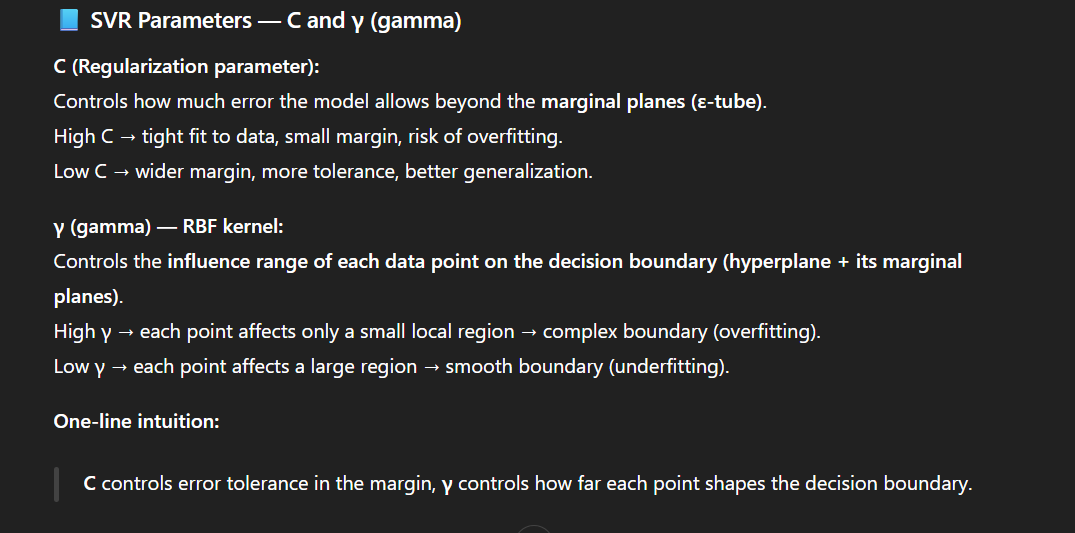

In [45]:
from sklearn.model_selection import GridSearchCV

# defining parameter range-:
param_grid = {
    'C':[0.1,1,10,1000],
    'gamma':[1,0.1,0.01,0.001,0.0001],
    'kernel':['rbf']
}

# we genrally use 'rbf' svm kernel as it is widley ued and mostly gives better results than other SVM kernels.

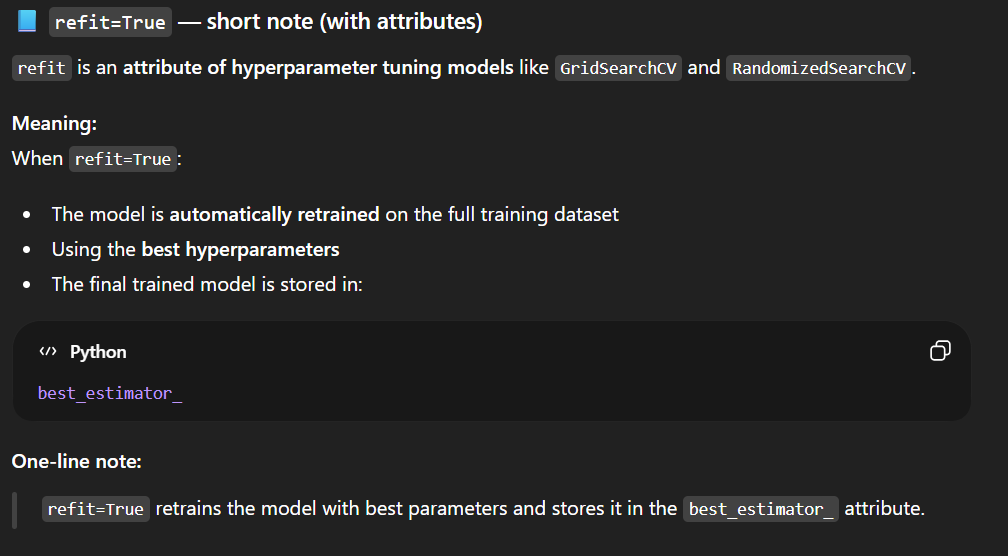

the default value of refit parameter is True.

In [46]:
grid = GridSearchCV(estimator=svr,param_grid=param_grid,cv=5,verbose=3,refit=True)

In [47]:
grid

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [48]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.067 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.058 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.145 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.025 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.089 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.013 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.021 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=0.1, kernel=rbf;, score=-0.010 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.124 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.050 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=0.01, kernel=rbf;, score=-0.053 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=0.01, kernel=rbf;

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [49]:
grid.best_params_

{'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}

In [50]:
grid.predict(X_test)

array([16.2552184 , 18.24650371, 14.32536037, 24.91463447, 14.61673052,
       23.33684165, 19.11663457, 29.45858274, 23.95267794, 21.59693253,
       26.41847732, 17.97651898, 11.44325222, 22.33188472, 19.10725257,
       13.21498859, 12.84466887, 11.80971455, 21.47235182, 18.08432898,
       13.28565053, 15.53547129, 13.9687171 , 11.64806986, 31.27393686,
       12.84466887, 17.82487161, 20.70657034, 14.25720269, 34.19760728,
       29.06175357, 30.95989335, 14.22383265, 15.84264818, 17.79285818,
       11.00555427, 20.78567381, 14.39445198, 21.00486364, 22.44930816,
       16.84843992, 21.88188852, 11.22788211, 24.8915194 , 13.20081643,
       13.87159891, 18.78854644, 14.22383265, 12.38064328, 18.71327137,
       20.71375165, 32.07908404, 19.62534666, 27.89357142,  7.89050396,
       17.52315794, 13.23316813, 13.25393434, 18.17569147, 13.3376643 ,
       17.46285063])

In [51]:
grid_predict = grid.predict(X_test)

In [52]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,grid_predict))
print(mean_absolute_error(y_test,grid_predict))

0.5081618245078687
3.8685147526100234


Due to HYPER-PARMETER TUNING of SVR-:

We got improved/increased R-squared score and lesser MAE value